In [1]:
# Cell 1: Colab-ready setup, imports, environment checks, and script path resolution.
try:
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "stable-baselines3[extra]", "gymnasium[atari,accept-rom-license]", "ale-py"])
except Exception as e:
    print(f"[WARNING] pip install failed (normal on Kaggle/restricted env): {e}")
    print("Attempting to import packages as-is.")

import csv
import datetime
import gc
import json
import os
import shutil
import subprocess
import sys
import textwrap
import time
import traceback
import warnings
from pathlib import Path
from typing import Dict, Tuple

warnings.filterwarnings("ignore", message="Gym has been unmaintained since 2022.*")

import matplotlib.pyplot as plt
import pandas as pd
import gymnasium as gym
import ale_py  # noqa: F401
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

_ = ale_py
_ = os

COLAB_FILES = None
COLAB_DRIVE = None
try:
    from google.colab import drive as _drive, files as _files  # type: ignore
    COLAB_DRIVE = _drive
    COLAB_FILES = _files
except Exception:
    pass

ENV_ID = "ALE/Tennis-v5"
MEMBER = "raissa"
TRAIN_LOG_PROGRESS_EVERY = 5_000

# Try to locate an existing project root first.
root_candidates = [
    Path.cwd().resolve(),
    Path('/content/Tenis_dqn_agent'),
    Path('/content/drive/MyDrive/Tenis_dqn_agent'),
]

PROJECT_ROOT = None
for candidate in root_candidates:
    if (candidate / "scripts" / "train.py").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    probe = Path.cwd().resolve()
    while probe != probe.parent:
        if (probe / "scripts" / "train.py").exists():
            PROJECT_ROOT = probe
            break
        probe = probe.parent

# Colab fallback: if repo scripts are missing, bootstrap train.py and play.py locally.
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd().resolve()
    print("[INFO] Repo scripts not found. Bootstrapping scripts/train.py and scripts/play.py in current directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
SCRIPTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_SCRIPT = SCRIPTS_DIR / "train.py"
PLAY_SCRIPT = SCRIPTS_DIR / "play.py"

TRAIN_PY_BOOTSTRAP = textwrap.dedent("""
#!/usr/bin/env python
# coding: utf-8

import argparse
import csv
import json
import os
import time
from pathlib import Path

import ale_py  # noqa: F401
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecMonitor

class EpisodeCSVLogger(BaseCallback):
    def __init__(self, csv_path: str, progress_every: int = 5000, verbose: int = 0):
        super().__init__(verbose)
        self.csv_path = csv_path
        self.progress_every = max(1, int(progress_every))
        self.rows = []
        self._last_progress_t = 0

    def _on_step(self) -> bool:
        saw_episode = False
        for info in self.locals.get(\"infos\", []):
            if \"episode\" in info:
                ep = info[\"episode\"]
                self.rows.append({
                    \"timestep\": self.num_timesteps,
                    \"ep_length\": ep.get(\"l\"),
                    \"ep_reward\": ep.get(\"r\"),
                    \"time\": round(time.time(), 2),
                    \"row_type\": \"episode_end\",
                })
                saw_episode = True
        if (not saw_episode) and (self.num_timesteps - self._last_progress_t) >= self.progress_every:
            self._last_progress_t = self.num_timesteps
            self.rows.append({
                \"timestep\": self.num_timesteps,
                \"ep_length\": \"\",
                \"ep_reward\": \"\",
                \"time\": round(time.time(), 2),
                \"row_type\": \"progress\",
            })
        return True

    def _on_training_end(self) -> None:
        os.makedirs(os.path.dirname(self.csv_path), exist_ok=True)
        fields = [\"timestep\", \"ep_length\", \"ep_reward\", \"time\", \"row_type\"]
        with open(self.csv_path, \"w\", newline=\"\", encoding=\"utf-8\") as f:
            writer = csv.DictWriter(f, fieldnames=fields)
            writer.writeheader()
            writer.writerows(self.rows)

def make_cnn_env(env_id: str, seed: int, render_mode=None):
    env = make_atari_env(env_id, n_envs=1, seed=seed, env_kwargs={\"render_mode\": render_mode})
    env = VecMonitor(env)
    env = VecFrameStack(env, n_stack=4)
    return env

def make_mlp_env(env_id: str, seed: int, render_mode=None):
    candidate_ids = list(dict.fromkeys([env_id, env_id.replace(\"-v5\", \"-ram-v5\"), \"ALE/Tennis-ram-v5\", \"Tennis-ram-v5\"]))
    last_err = None
    for ram_env_id in candidate_ids:
        try:
            env = DummyVecEnv([lambda ram_env_id=ram_env_id, render_mode=render_mode: Monitor(gym.make(
                ram_env_id, obs_type=\"ram\", frameskip=4, repeat_action_probability=0.0, render_mode=render_mode
            ))])
            env.seed(seed)
            env = VecMonitor(env)
            return env
        except Exception as err:
            last_err = err
    raise RuntimeError(f\"Could not create RAM env. Tried {candidate_ids}. Last error: {last_err}\")

def append_eval_summary_row(csv_path: Path, timestep: int, mean_reward: float):
    fields = [\"timestep\", \"ep_length\", \"ep_reward\", \"time\", \"row_type\"]
    needs_header = (not csv_path.exists()) or csv_path.stat().st_size == 0
    with open(csv_path, \"a\", newline=\"\", encoding=\"utf-8\") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        if needs_header:
            writer.writeheader()
        writer.writerow({
            \"timestep\": int(timestep),
            \"ep_length\": \"\",
            \"ep_reward\": float(mean_reward),
            \"time\": round(time.time(), 2),
            \"row_type\": \"eval_summary\",
        })

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument(\"--member\", type=str, required=True)
    p.add_argument(\"--experiment\", type=str, required=True)
    p.add_argument(\"--env-id\", type=str, default=\"ALE/Tennis-v5\")
    p.add_argument(\"--policy\", type=str, choices=[\"CnnPolicy\", \"MlpPolicy\"], default=\"CnnPolicy\")
    p.add_argument(\"--total-timesteps\", type=int, default=50000)
    p.add_argument(\"--seed\", type=int, default=42)
    p.add_argument(\"--device\", type=str, default=\"auto\")
    p.add_argument(\"--learning-rate\", type=float, default=1e-4)
    p.add_argument(\"--gamma\", type=float, default=0.99)
    p.add_argument(\"--batch-size\", type=int, default=32)
    p.add_argument(\"--buffer-size\", type=int, default=100000)
    p.add_argument(\"--learning-starts\", type=int, default=2000)
    p.add_argument(\"--train-freq\", type=int, default=4)
    p.add_argument(\"--gradient-steps\", type=int, default=1)
    p.add_argument(\"--target-update-interval\", type=int, default=10000)
    p.add_argument(\"--exploration-initial-eps\", type=float, default=1.0)
    p.add_argument(\"--exploration-final-eps\", type=float, default=0.01)
    p.add_argument(\"--exploration-fraction\", type=float, default=0.1)
    p.add_argument(\"--eval-freq\", type=int, default=10000)
    p.add_argument(\"--eval-episodes\", type=int, default=3)
    p.add_argument(\"--log-progress-every\", type=int, default=5000)
    return p.parse_args()

def main():
    args = parse_args()
    base_dir = Path(\"results\") / args.member
    model_dir = base_dir / \"models\"
    log_dir = base_dir / \"logs\"
    experiment_dir = base_dir / args.experiment
    model_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)
    experiment_dir.mkdir(parents=True, exist_ok=True)

    training_csv_path = log_dir / f\"{args.experiment}_training_metrics.csv\"
    eval_json_path = experiment_dir / f\"{args.experiment}_eval.json\"
    final_model_path = model_dir / f\"{args.experiment}.zip\"
    best_model_dir = model_dir / f\"{args.experiment}_best\"
    eval_log_dir = experiment_dir / \"eval_logs\"

    if args.policy == \"CnnPolicy\":
        train_env = make_cnn_env(args.env_id, seed=args.seed)
        eval_env = make_cnn_env(args.env_id, seed=args.seed + 100)
        final_eval_env = make_cnn_env(args.env_id, seed=args.seed + 200)
    else:
        train_env = make_mlp_env(args.env_id, seed=args.seed)
        eval_env = make_mlp_env(args.env_id, seed=args.seed + 100)
        final_eval_env = make_mlp_env(args.env_id, seed=args.seed + 200)

    episode_logger = EpisodeCSVLogger(str(training_csv_path), progress_every=args.log_progress_every)
    eval_callback = EvalCallback(eval_env, best_model_save_path=str(best_model_dir), log_path=str(eval_log_dir), eval_freq=args.eval_freq, n_eval_episodes=args.eval_episodes, deterministic=True, render=False)

    model = DQN(
        policy=args.policy,
        env=train_env,
        learning_rate=args.learning_rate,
        gamma=args.gamma,
        batch_size=args.batch_size,
        buffer_size=args.buffer_size,
        learning_starts=args.learning_starts,
        train_freq=args.train_freq,
        gradient_steps=args.gradient_steps,
        target_update_interval=args.target_update_interval,
        exploration_initial_eps=args.exploration_initial_eps,
        exploration_final_eps=args.exploration_final_eps,
        exploration_fraction=args.exploration_fraction,
        tensorboard_log=str(log_dir / \"tensorboard\"),
        seed=args.seed,
        device=args.device,
        verbose=1,
    )

    t0 = time.time()
    model.learn(total_timesteps=args.total_timesteps, callback=[episode_logger, eval_callback], progress_bar=False)
    train_minutes = (time.time() - t0) / 60.0
    model.save(str(final_model_path.with_suffix(\"\")))

    mean_reward, std_reward = evaluate_policy(model, final_eval_env, n_eval_episodes=args.eval_episodes, deterministic=True)
    append_eval_summary_row(training_csv_path, args.total_timesteps, float(mean_reward))

    eval_summary = {
        \"member\": args.member,
        \"experiment\": args.experiment,
        \"policy\": args.policy,
        \"env_id\": args.env_id,
        \"mean_reward\": float(mean_reward),
        \"std_reward\": float(std_reward),
        \"train_minutes\": float(train_minutes),
        \"model_path\": str(final_model_path),
        \"training_csv_path\": str(training_csv_path),
        \"total_timesteps\": args.total_timesteps,
    }
    with open(eval_json_path, \"w\", encoding=\"utf-8\") as f:
        json.dump(eval_summary, f, indent=2)

    train_env.close()
    eval_env.close()
    final_eval_env.close()
    print(f\"[DONE] {args.experiment} mean={mean_reward:.2f} std={std_reward:.2f}\")

if __name__ == \"__main__\":
    main()
""").strip() + "\n"

PLAY_PY_BOOTSTRAP = textwrap.dedent("""
#!/usr/bin/env python
# coding: utf-8

import argparse
import time
from pathlib import Path

import ale_py  # noqa: F401
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecVideoRecorder

def make_cnn_env(env_id: str, seed: int, render_mode=None):
    env = make_atari_env(env_id, n_envs=1, seed=seed, env_kwargs={\"render_mode\": render_mode})
    env = VecFrameStack(env, n_stack=4)
    return env

def make_mlp_env(env_id: str, seed: int, render_mode=None):
    candidate_ids = list(dict.fromkeys([env_id, env_id.replace(\"-v5\", \"-ram-v5\"), \"ALE/Tennis-ram-v5\", \"Tennis-ram-v5\"]))
    last_err = None
    for ram_env_id in candidate_ids:
        try:
            env = DummyVecEnv([lambda ram_env_id=ram_env_id, render_mode=render_mode: Monitor(gym.make(
                ram_env_id, obs_type=\"ram\", frameskip=4, repeat_action_probability=0.0, render_mode=render_mode
            ))])
            env.seed(seed)
            return env
        except Exception as err:
            last_err = err
    raise RuntimeError(f\"Could not create RAM env. Tried {candidate_ids}. Last error: {last_err}\")

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument(\"--model-path\", type=str, required=True)
    p.add_argument(\"--env-id\", type=str, default=\"ALE/Tennis-v5\")
    p.add_argument(\"--policy\", type=str, choices=[\"CnnPolicy\", \"MlpPolicy\"], default=\"CnnPolicy\")
    p.add_argument(\"--episodes\", type=int, default=1)
    p.add_argument(\"--seed\", type=int, default=42)
    p.add_argument(\"--max-steps\", type=int, default=2000)
    p.add_argument(\"--device\", type=str, default=\"auto\")
    p.add_argument(\"--render\", action=\"store_true\")
    p.add_argument(\"--record-video\", action=\"store_true\")
    p.add_argument(\"--video-dir\", type=str, default=\"results/play_videos\")
    p.add_argument(\"--video-prefix\", type=str, default=\"dqn_play\")
    p.add_argument(\"--fps-sleep\", type=float, default=0.0)
    return p.parse_args()

def main():
    args = parse_args()
    model_path = Path(args.model_path)
    if not model_path.exists():
        raise FileNotFoundError(f\"Model not found: {model_path}\")

    render_mode = \"human\" if args.render else (\"rgb_array\" if args.record_video else None)
    env = make_cnn_env(args.env_id, args.seed, render_mode) if args.policy == \"CnnPolicy\" else make_mlp_env(args.env_id, args.seed, render_mode)

    video_dir = Path(args.video_dir)
    if args.record_video:
        video_dir.mkdir(parents=True, exist_ok=True)
        env = VecVideoRecorder(env, video_folder=str(video_dir), record_video_trigger=lambda step: step == 0, video_length=args.max_steps, name_prefix=args.video_prefix)

    model = DQN.load(str(model_path), device=args.device)
    rewards = []
    for ep in range(args.episodes):
        env.seed(args.seed + ep)
        obs = env.reset()
        done = [False]
        ep_reward = 0.0
        step_count = 0
        while not done[0] and step_count < args.max_steps:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _ = env.step(action)
            ep_reward += float(reward[0])
            step_count += 1
            if args.render and args.fps_sleep > 0:
                time.sleep(args.fps_sleep)
        rewards.append(ep_reward)
        print(f\"Episode {ep + 1}/{args.episodes} | steps={step_count} | reward={ep_reward:.2f}\")

    env.close()
    mean_reward = sum(rewards) / len(rewards) if rewards else 0.0
    print(f\"Average reward over {len(rewards)} episodes: {mean_reward:.2f}\")
    if args.record_video and video_dir.exists():
        mp4_files = sorted(video_dir.glob(\"*.mp4\"), key=lambda p: p.stat().st_mtime)
        if mp4_files:
            print(f\"Video saved: {mp4_files[-1]}\")

if __name__ == \"__main__\":
    main()
""").strip() + "\n"

if not TRAIN_SCRIPT.exists():
    TRAIN_SCRIPT.write_text(TRAIN_PY_BOOTSTRAP, encoding="utf-8")
    print(f"[BOOTSTRAP] Created {TRAIN_SCRIPT}")

if not PLAY_SCRIPT.exists():
    PLAY_SCRIPT.write_text(PLAY_PY_BOOTSTRAP, encoding="utf-8")
    print(f"[BOOTSTRAP] Created {PLAY_SCRIPT}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Train script: {TRAIN_SCRIPT}")
print(f"Play script : {PLAY_SCRIPT}")

# Local artifact structure
BASE_DIR = PROJECT_ROOT / "results" / MEMBER
MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
VIDEO_DIR = BASE_DIR / "videos"

for p in [MODEL_DIR, LOG_DIR, TABLE_DIR, VIDEO_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DRIVE_MOUNTED = False
DRIVE_EXPORT_DIR = None
if COLAB_DRIVE is not None:
    try:
        COLAB_DRIVE.mount('/content/drive')
        DRIVE_MOUNTED = True
        DRIVE_EXPORT_DIR = Path('/content/drive/MyDrive/Tenis_dqn_agent') / MEMBER
        DRIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Google Drive mounted. Export path: {DRIVE_EXPORT_DIR}")
    except Exception:
        print("Google Drive mount failed.")
else:
    print("Google Drive not mounted (this is fine outside Colab).")

test_env = make_atari_env(ENV_ID, n_envs=1, seed=42)
test_env = VecFrameStack(test_env, n_stack=4)
test_env.close()
print(f"Environment ready: {ENV_ID}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[INFO] Repo scripts not found. Bootstrapping scripts/train.py and scripts/play.py in current directory.
[BOOTSTRAP] Created /content/scripts/train.py
[BOOTSTRAP] Created /content/scripts/play.py
Project root: /content
Train script: /content/scripts/train.py
Play script : /content/scripts/play.py
Mounted at /content/drive
Google Drive mounted. Export path: /content/drive/MyDrive/Tenis_dqn_agent/raissa
Environment ready: ALE/Tennis-v5


In [2]:
# Cell 2: Reusable training utilities (supports both CnnPolicy and MlpPolicy)
class EpisodeCSVLogger(BaseCallback):
    def __init__(self, run_name: str, csv_path: str, log_path: str, verbose: int = 1, progress_every: int = 10_000):
        super().__init__(verbose)
        self.run_name = run_name
        self.csv_path = csv_path
        self.log_path = log_path
        self.progress_every = int(progress_every)
        self._last_progress_t = 0
        self.rows = []

    def _on_training_start(self) -> None:
        Path(self.csv_path).parent.mkdir(parents=True, exist_ok=True)
        Path(self.log_path).parent.mkdir(parents=True, exist_ok=True)
        with open(self.log_path, "a", encoding="utf-8") as f:
            f.write(f"[{self._ts()}] [RUN {self.run_name}] logging started\n")
        self._last_progress_t = 0

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                ep = info["episode"]
                ep_len = ep.get("l")
                ep_rew = ep.get("r")
                self.rows.append((self.num_timesteps, ep_len, ep_rew))
                eps = getattr(self.model, "exploration_rate", None)
                line = f"[{self._ts()}] [RUN {self.run_name}] t={self.num_timesteps} | episode_end len={ep_len} reward={ep_rew:.2f}"
                if eps is not None:
                    line += f" | eps={eps:.4f}"
                print(line, flush=True)
                with open(self.log_path, "a", encoding="utf-8") as f:
                    f.write(line + "\n")

        # Heartbeat progress logs for long episodes (common in Atari RAM runs).
        if self.progress_every > 0 and (self.num_timesteps - self._last_progress_t) >= self.progress_every:
            self._last_progress_t = self.num_timesteps
            eps = getattr(self.model, "exploration_rate", None)
            line = f"[{self._ts()}] [RUN {self.run_name}] progress t={self.num_timesteps}"
            if eps is not None:
                line += f" | eps={eps:.4f}"
            print(line, flush=True)
            with open(self.log_path, "a", encoding="utf-8") as f:
                f.write(line + "\n")
        return True

    def _on_training_end(self) -> None:
        with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["timestep", "ep_length", "ep_reward"])
            writer.writerows(self.rows)
        with open(self.log_path, "a", encoding="utf-8") as f:
            f.write(f"[{self._ts()}] [RUN {self.run_name}] episode CSV saved -> {self.csv_path}\n")
        print(f"Saved episode CSV to {self.csv_path}")

    @staticmethod
    def _ts() -> str:
        return datetime.datetime.now().strftime("%H:%M:%S")


def make_env(policy: str, seed: int):
    if policy == "CnnPolicy":
        env = make_atari_env(ENV_ID, n_envs=1, seed=seed)
        env = VecFrameStack(env, n_stack=4)
        return env

    # MLP branch: force RAM observations and avoid image wrappers that can trigger cv2 channel errors.
    candidate_ids = [
        ENV_ID,
        ENV_ID.replace("-v5", "-ram-v5"),
        "ALE/Tennis-ram-v5",
        "Tennis-ram-v5",
    ]

    last_err = None
    for ram_env_id in dict.fromkeys(candidate_ids):
        try:
            return DummyVecEnv([
                lambda ram_env_id=ram_env_id, seed=seed: gym.make(
                    ram_env_id,
                    obs_type="ram",
                    frameskip=4,
                    repeat_action_probability=0.0,
                    render_mode=None,
                )
            ])
        except Exception as err:
            last_err = err

    raise RuntimeError(
        "Could not create a RAM Atari env for MlpPolicy. "
        f"Tried ids={candidate_ids}. Last error: {last_err}"
    ) from last_err


def train_experiment(
    name: str,
    policy: str,
    hp: Dict,
    total_timesteps: int = 300_000,
    seed: int = 42,
    eval_episodes: int = 3,
    device: str = "auto",
) -> Tuple[Dict, DQN]:
    csv_log = str(LOG_DIR / f"{name}_training_metrics.csv")
    run_log = str(LOG_DIR / f"run_{name}.log")
    callback = EpisodeCSVLogger(run_name=name, csv_path=csv_log, log_path=run_log, verbose=1, progress_every=10_000)

    env = make_env(policy=policy, seed=seed)
    eval_env = make_env(policy=policy, seed=seed + 100)

    model = DQN(
        policy,
        env,
        seed=seed,
        device=device,
        tensorboard_log=str(LOG_DIR / "tensorboard" / name),
        optimize_memory_usage=False,
        **hp,
    )

    start_msg = f"[{datetime.datetime.now().strftime('%H:%M:%S')}] [RUN {name}] START {policy} training {total_timesteps} steps | hp={hp}"
    print(start_msg, flush=True)
    with open(run_log, "a", encoding="utf-8") as f:
        f.write(start_msg + "\n")

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
    minutes = (time.time() - t0) / 60.0

    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=eval_episodes, deterministic=True)

    env.close()
    eval_env.close()

    end_msg = f"[{datetime.datetime.now().strftime('%H:%M:%S')}] [RUN {name}] END mean_reward={mean_r:.2f} +/- {std_r:.2f} | train_minutes={minutes:.2f}"
    print(end_msg, flush=True)
    with open(run_log, "a", encoding="utf-8") as f:
        f.write(end_msg + "\n")

    metrics = {
        "name": name,
        "policy": policy,
        "mean_reward": float(mean_r),
        "std_reward": float(std_r),
        "train_minutes": float(minutes),
        "learning_rate": hp["learning_rate"],
        "gamma": hp["gamma"],
        "batch_size": hp["batch_size"],
        "exploration_initial_eps": hp["exploration_initial_eps"],
        "exploration_final_eps": hp["exploration_final_eps"],
        "exploration_fraction": hp["exploration_fraction"],
    }
    return metrics, model

print("Training utilities ready.")

Training utilities ready.


In [3]:
# Cell 3: Define 10 Raissa-specific hyperparameter experiments
# 5 CNN + 5 MLP experiments.
# MLP split:
# - 2 paired runs use the same hyperparameters as CNN runs (direct policy comparison)
# - 3 runs use independent MLP-specific values with fixed LR and varied gamma/epsilon

experiments = [
    {
        "name": "raissa-exp01-cnn-baseline",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp02-cnn-low-lr",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=5e-5, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp03-cnn-gamma-097",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.97, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp04-cnn-batch-64",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=120_000, train_freq=4, gradient_steps=1, target_update_interval=12_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp05-cnn-fast-epsilon-decay",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=120_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.05, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },

    # Paired MLP runs (same HP as selected CNN runs)
    {
        "name": "raissa-exp06-mlp-paired-baseline",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp07-mlp-paired-low-lr",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=5e-5, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },

    # Independent MLP runs (fixed LR=1e-4, varied gamma/epsilon)
    {
        "name": "raissa-exp08-mlp-gamma-097-fast-eps",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.97, batch_size=64, buffer_size=80_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.05, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp09-mlp-gamma-0995-mid-eps",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.995, batch_size=64, buffer_size=80_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.15, exploration_initial_eps=1.0, exploration_final_eps=0.02, verbose=0),
    },
    {
        "name": "raissa-exp10-mlp-gamma-0999-slow-eps",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.999, batch_size=64, buffer_size=80_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.30, exploration_initial_eps=1.0, exploration_final_eps=0.05, verbose=0),
    },
]

print(f"Prepared {len(experiments)} experiment configs.")
pd.DataFrame(
    [
        {
            "name": e["name"],
            "policy": e["policy"],
            "learning_rate": e["hp"]["learning_rate"],
            "gamma": e["hp"]["gamma"],
            "batch_size": e["hp"]["batch_size"],
            "eps_start": e["hp"]["exploration_initial_eps"],
            "eps_end": e["hp"]["exploration_final_eps"],
            "eps_frac": e["hp"]["exploration_fraction"],
        }
        for e in experiments
    ]
)

Prepared 10 experiment configs.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,learning_rate,gamma,batch_size,eps_start,eps_end,eps_frac
0,raissa-exp01-cnn-baseline,CnnPolicy,0.00010,0.990,32,1.0,0.01,0.10
1,raissa-exp02-cnn-low-lr,CnnPolicy,0.00005,0.990,32,1.0,0.01,0.10
2,raissa-exp03-cnn-gamma-097,CnnPolicy,0.00010,0.970,32,1.0,0.01,0.10
3,raissa-exp04-cnn-batch-64,CnnPolicy,0.00010,0.990,64,1.0,0.01,0.10
4,raissa-exp05-cnn-fast-epsilon-decay,CnnPolicy,0.00010,0.990,64,1.0,0.01,0.05
5,raissa-exp06-mlp-paired-baseline,MlpPolicy,0.00010,0.990,32,1.0,0.01,0.10
6,raissa-exp07-mlp-paired-low-lr,MlpPolicy,0.00005,0.990,32,1.0,0.01,0.10
7,raissa-exp08-mlp-gamma-097-fast-eps,MlpPolicy,0.00010,0.970,64,1.0,0.01,0.05
8,raissa-exp09-mlp-gamma-0995-mid-eps,MlpPolicy,0.00010,0.995,64,1.0,0.02,0.15
9,raissa-exp10-mlp-gamma-0999-slow-eps,MlpPolicy,0.00010,0.999,64,1.0,0.05,0.30


## 3b · Policy Comparison: CNN vs MLP with Same Hyperparameters
This optional cell runs a quick side-by-side comparison using identical hyperparameters but different policies. This demonstrates why CNN is typically superior for pixel-based Atari: the CNN agent learns to play while the MLP agent struggles to achieve positive rewards.


In [4]:
# Optional: Quick policy comparison via scripts/train.py with identical hyperparameters.
# This demonstrates why CNN typically outperforms MLP on pixel-based Atari tasks.

COMPARISON_TIMESTEPS = 50_000
COMPARISON_SEED = 42
COMPARISON_EVAL_EPISODES = 3
COMPARISON_DEVICE = "auto"

if not TRAIN_SCRIPT.exists():
    raise FileNotFoundError(f"train.py not found at: {TRAIN_SCRIPT}")

shared_hp = dict(
    learning_rate=1e-4,
    gamma=0.99,
    batch_size=32,
    buffer_size=100_000,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=10_000,
    exploration_fraction=0.10,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.01,
)

comparison_results = []

for policy_name in ["CnnPolicy", "MlpPolicy"]:
    comparison_name = f"policy-comparison-{policy_name.lower()}-{COMPARISON_TIMESTEPS//1000}k"
    eval_json_path = BASE_DIR / comparison_name / f"{comparison_name}_eval.json"

    cmd = [
        sys.executable,
        str(TRAIN_SCRIPT),
        "--member", MEMBER,
        "--experiment", comparison_name,
        "--env-id", ENV_ID,
        "--policy", policy_name,
        "--total-timesteps", str(COMPARISON_TIMESTEPS),
        "--seed", str(COMPARISON_SEED),
        "--device", COMPARISON_DEVICE,
        "--learning-rate", str(shared_hp["learning_rate"]),
        "--gamma", str(shared_hp["gamma"]),
        "--batch-size", str(shared_hp["batch_size"]),
        "--buffer-size", str(shared_hp["buffer_size"]),
        "--train-freq", str(shared_hp["train_freq"]),
        "--gradient-steps", str(shared_hp["gradient_steps"]),
        "--target-update-interval", str(shared_hp["target_update_interval"]),
        "--exploration-initial-eps", str(shared_hp["exploration_initial_eps"]),
        "--exploration-final-eps", str(shared_hp["exploration_final_eps"]),
        "--exploration-fraction", str(shared_hp["exploration_fraction"]),
        "--eval-episodes", str(COMPARISON_EVAL_EPISODES),
        "--log-progress-every", str(TRAIN_LOG_PROGRESS_EVERY),
    ]

    print(f"\n{'=' * 70}")
    print(f"Running {policy_name} with {COMPARISON_TIMESTEPS:,} timesteps...")
    print(f"{'=' * 70}")

    run = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)
    if run.stdout:
        print(run.stdout[-1500:])
    if run.returncode != 0:
        err_msg = run.stderr[-1500:] if run.stderr else f"train.py failed with code {run.returncode}"
        print(f"[FAIL] {policy_name} failed: {err_msg}")
        continue

    if not eval_json_path.exists():
        print(f"[FAIL] Missing eval JSON: {eval_json_path}")
        continue

    with open(eval_json_path, "r", encoding="utf-8") as f:
        eval_summary = json.load(f)

    comparison_results.append({
        "name": comparison_name,
        "policy": policy_name,
        "mean_reward": float(eval_summary["mean_reward"]),
        "std_reward": float(eval_summary["std_reward"]),
        "train_minutes": float(eval_summary["train_minutes"]),
    })

if len(comparison_results) == 2:
    comparison_df = pd.DataFrame(comparison_results)
    print(f"\n{'=' * 70}")
    print("POLICY COMPARISON RESULTS")
    print(f"{'=' * 70}")
    print(comparison_df[["name", "policy", "mean_reward", "std_reward", "train_minutes"]])

    cnn_reward = comparison_df[comparison_df["policy"] == "CnnPolicy"]["mean_reward"].values
    mlp_reward = comparison_df[comparison_df["policy"] == "MlpPolicy"]["mean_reward"].values

    if len(cnn_reward) > 0 and len(mlp_reward) > 0:
        cnn_val = float(cnn_reward[0])
        mlp_val = float(mlp_reward[0])
        print("\nAnalysis:")
        print(f"   CNN mean reward  : {cnn_val:>8.2f}")
        print(f"   MLP mean reward  : {mlp_val:>8.2f}")
        print(f"   Difference (CNN-MLP): {cnn_val - mlp_val:>8.2f} points")
        if cnn_val > mlp_val:
            if mlp_val != 0:
                pct = ((cnn_val - mlp_val) / abs(mlp_val)) * 100
                print(f"   CNN outperforms MLP by {pct:.1f}%")
            else:
                print("   CNN outperforms MLP by a large margin (MLP near zero reward)")
        else:
            print("   Note: MLP performed better (unusual for pixel-based tasks)")
else:
    print("Could not complete comparison - ensure both policies ran successfully.")


Running CnnPolicy with 50,000 timesteps...
   |          |
|    episodes         | 12       |
|    fps              | 40       |
|    time_elapsed     | 928      |
|    total_timesteps  | 37829    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.76e-05 |
|    n_updates        | 8957     |
----------------------------------
Eval num_timesteps=40000, episode_reward=-0.33 +/- 0.94
Episode length: 6743.33 +/- 2.05
----------------------------------
| eval/               |          |
|    mean_ep_length   | 6.74e+03 |
|    mean_reward      | -0.333   |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 40000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 5.08e-05 |
|    n_updates        | 9499     |
----------------------------------
New best mean reward!
Eval num_timesteps=50000, episode_reward=-1.00 +/- 0.00
Epi

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Cell 4: Run all experiments via scripts/train.py and build results table
TOTAL_TIMESTEPS = 50_000
SEED = 42
EVAL_EPISODES = 3
DEVICE = "auto"

BEST_MODEL_PATH = MODEL_DIR / "best_dqn_tennis.zip"
ASSIGNMENT_MODEL_PATH = MODEL_DIR / "dqn_model.zip"

if not TRAIN_SCRIPT.exists():
    raise FileNotFoundError(f"train.py not found at: {TRAIN_SCRIPT}")

results = []
failed_runs = []
best_record = None
best_mean_reward = None

for exp in experiments:
    name = exp["name"]
    policy = exp["policy"]
    hp = exp["hp"]
    eval_json_path = BASE_DIR / name / f"{name}_eval.json"

    cmd = [
        sys.executable,
        str(TRAIN_SCRIPT),
        "--member", MEMBER,
        "--experiment", name,
        "--env-id", ENV_ID,
        "--policy", policy,
        "--total-timesteps", str(TOTAL_TIMESTEPS),
        "--seed", str(SEED),
        "--device", DEVICE,
        "--learning-rate", str(hp["learning_rate"]),
        "--gamma", str(hp["gamma"]),
        "--batch-size", str(hp["batch_size"]),
        "--buffer-size", str(hp["buffer_size"]),
        "--train-freq", str(hp["train_freq"]),
        "--gradient-steps", str(hp["gradient_steps"]),
        "--target-update-interval", str(hp["target_update_interval"]),
        "--exploration-initial-eps", str(hp["exploration_initial_eps"]),
        "--exploration-final-eps", str(hp["exploration_final_eps"]),
        "--exploration-fraction", str(hp["exploration_fraction"]),
        "--eval-episodes", str(EVAL_EPISODES),
        "--log-progress-every", str(TRAIN_LOG_PROGRESS_EVERY),
    ]

    print(f"\n===== Running {name} ({policy}) via train.py =====")
    run = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)
    if run.stdout:
        print(run.stdout[-2000:])
    if run.returncode != 0:
        err_msg = run.stderr[-2000:] if run.stderr else f"train.py failed with code {run.returncode}"
        print(f"[ERROR] {name} failed")
        print(err_msg)
        failed_runs.append({"name": name, "policy": policy, "error": err_msg})
        continue

    if not eval_json_path.exists():
        err_msg = f"Missing eval summary JSON: {eval_json_path}"
        print(f"[ERROR] {err_msg}")
        failed_runs.append({"name": name, "policy": policy, "error": err_msg})
        continue

    with open(eval_json_path, "r", encoding="utf-8") as f:
        eval_summary = json.load(f)

    metrics = {
        "name": name,
        "policy": policy,
        "mean_reward": float(eval_summary["mean_reward"]),
        "std_reward": float(eval_summary["std_reward"]),
        "train_minutes": float(eval_summary["train_minutes"]),
        "learning_rate": hp["learning_rate"],
        "gamma": hp["gamma"],
        "batch_size": hp["batch_size"],
        "exploration_initial_eps": hp["exploration_initial_eps"],
        "exploration_final_eps": hp["exploration_final_eps"],
        "exploration_fraction": hp["exploration_fraction"],
        "model_path": eval_summary.get("model_path", str(MODEL_DIR / f"{name}.zip")),
        "eval_json_path": str(eval_json_path),
    }
    results.append(metrics)

    model_path = Path(metrics["model_path"])
    if (best_mean_reward is None) or (metrics["mean_reward"] > best_mean_reward):
        best_mean_reward = metrics["mean_reward"]
        best_record = dict(metrics)
        if model_path.exists():
            shutil.copy(str(model_path), str(BEST_MODEL_PATH))
            shutil.copy(str(model_path), str(ASSIGNMENT_MODEL_PATH))
            print(f"[BEST] Updated -> {BEST_MODEL_PATH}")
            print(f"[ASSIGNMENT] Updated -> {ASSIGNMENT_MODEL_PATH}")

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
    print("\nTop result:")
    display(results_df.head(1))
else:
    print("No successful runs yet.")

failed_df = pd.DataFrame(failed_runs)
if not failed_df.empty:
    print("\nFailed runs summary:")
    display(failed_df)

results_df


===== Running raissa-exp01-cnn-baseline (CnnPolicy) via train.py =====
ollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 30000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 8.46e-05 |
|    n_updates        | 6999     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.15e+03 |
|    ep_rew_mean      | -14.4    |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 12       |
|    fps              | 39       |
|    time_elapsed     | 965      |
|    total_timesteps  | 37829    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.76e-05 |
|    n_updates        | 8957     |
----------------------------------
Eval num_timesteps=40000, episode_reward=-0.33 +/- 0.94
Episode length: 6743.33 +/- 2.05
--

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,mean_reward,std_reward,train_minutes,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,model_path,eval_json_path
0,raissa-exp05-cnn-fast-epsilon-decay,CnnPolicy,-0.333333,0.942809,32.541673,0.0001,0.99,64,1.0,0.01,0.05,results/raissa/models/raissa-exp05-cnn-fast-ep...,/content/results/raissa/raissa-exp05-cnn-fast-...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,mean_reward,std_reward,train_minutes,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,model_path,eval_json_path
0,raissa-exp05-cnn-fast-epsilon-decay,CnnPolicy,-0.333333,0.942809,32.541673,0.00010,0.990,64,1.0,0.01,0.05,results/raissa/models/raissa-exp05-cnn-fast-ep...,/content/results/raissa/raissa-exp05-cnn-fast-...
1,raissa-exp01-cnn-baseline,CnnPolicy,-1.000000,0.000000,22.952055,0.00010,0.990,32,1.0,0.01,0.10,results/raissa/models/raissa-exp01-cnn-baselin...,/content/results/raissa/raissa-exp01-cnn-basel...
2,raissa-exp02-cnn-low-lr,CnnPolicy,-1.000000,0.000000,23.748941,0.00005,0.990,32,1.0,0.01,0.10,results/raissa/models/raissa-exp02-cnn-low-lr.zip,/content/results/raissa/raissa-exp02-cnn-low-l...
3,raissa-exp03-cnn-gamma-097,CnnPolicy,-1.000000,0.000000,21.256691,0.00010,0.970,32,1.0,0.01,0.10,results/raissa/models/raissa-exp03-cnn-gamma-0...,/content/results/raissa/raissa-exp03-cnn-gamma...
4,raissa-exp04-cnn-batch-64,CnnPolicy,-1.000000,0.000000,32.527165,0.00010,0.990,64,1.0,0.01,0.10,results/raissa/models/raissa-exp04-cnn-batch-6...,/content/results/raissa/raissa-exp04-cnn-batch...
5,raissa-exp08-mlp-gamma-097-fast-eps,MlpPolicy,-7.666667,8.013877,2.998289,0.00010,0.970,64,1.0,0.01,0.05,results/raissa/models/raissa-exp08-mlp-gamma-0...,/content/results/raissa/raissa-exp08-mlp-gamma...
6,raissa-exp10-mlp-gamma-0999-slow-eps,MlpPolicy,-9.000000,0.000000,3.320446,0.00010,0.999,64,1.0,0.05,0.30,results/raissa/models/raissa-exp10-mlp-gamma-0...,/content/results/raissa/raissa-exp10-mlp-gamma...
7,raissa-exp06-mlp-paired-baseline,MlpPolicy,-9.333333,0.942809,4.368831,0.00010,0.990,32,1.0,0.01,0.10,results/raissa/models/raissa-exp06-mlp-paired-...,/content/results/raissa/raissa-exp06-mlp-paire...
8,raissa-exp07-mlp-paired-low-lr,MlpPolicy,-9.666667,0.942809,4.833291,0.00005,0.990,32,1.0,0.01,0.10,results/raissa/models/raissa-exp07-mlp-paired-...,/content/results/raissa/raissa-exp07-mlp-paire...
9,raissa-exp09-mlp-gamma-0995-mid-eps,MlpPolicy,-24.000000,0.000000,2.958738,0.00010,0.995,64,1.0,0.02,0.15,results/raissa/models/raissa-exp09-mlp-gamma-0...,/content/results/raissa/raissa-exp09-mlp-gamma...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# Cell 5: Save results table locally and as markdown-ready table for README
RESULTS_CSV = TABLE_DIR / "raissa_hyperparameter_results.csv"
RESULTS_MD = TABLE_DIR / "raissa_hyperparameter_results.md"

if results_df.empty:
    print("results_df is empty. Run Cell 4 first.")
else:
    results_df.to_csv(RESULTS_CSV, index=False)
    print(f"Saved CSV -> {RESULTS_CSV}")

    display_cols = [
        "name",
        "policy",
        "learning_rate",
        "gamma",
        "batch_size",
        "exploration_initial_eps",
        "exploration_final_eps",
        "exploration_fraction",
        "mean_reward",
        "std_reward",
        "train_minutes",
    ]
    md_df = results_df[display_cols].copy()
    md_text = md_df.to_markdown(index=False)
    RESULTS_MD.write_text(md_text, encoding="utf-8")
    print(f"Saved markdown table -> {RESULTS_MD}")

    display(md_df)

Saved CSV -> /content/results/raissa/tables/raissa_hyperparameter_results.csv
Saved markdown table -> /content/results/raissa/tables/raissa_hyperparameter_results.md


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,mean_reward,std_reward,train_minutes
0,raissa-exp05-cnn-fast-epsilon-decay,CnnPolicy,0.00010,0.990,64,1.0,0.01,0.05,-0.333333,0.942809,32.541673
1,raissa-exp01-cnn-baseline,CnnPolicy,0.00010,0.990,32,1.0,0.01,0.10,-1.000000,0.000000,22.952055
2,raissa-exp02-cnn-low-lr,CnnPolicy,0.00005,0.990,32,1.0,0.01,0.10,-1.000000,0.000000,23.748941
3,raissa-exp03-cnn-gamma-097,CnnPolicy,0.00010,0.970,32,1.0,0.01,0.10,-1.000000,0.000000,21.256691
4,raissa-exp04-cnn-batch-64,CnnPolicy,0.00010,0.990,64,1.0,0.01,0.10,-1.000000,0.000000,32.527165
5,raissa-exp08-mlp-gamma-097-fast-eps,MlpPolicy,0.00010,0.970,64,1.0,0.01,0.05,-7.666667,8.013877,2.998289
6,raissa-exp10-mlp-gamma-0999-slow-eps,MlpPolicy,0.00010,0.999,64,1.0,0.05,0.30,-9.000000,0.000000,3.320446
7,raissa-exp06-mlp-paired-baseline,MlpPolicy,0.00010,0.990,32,1.0,0.01,0.10,-9.333333,0.942809,4.368831
8,raissa-exp07-mlp-paired-low-lr,MlpPolicy,0.00005,0.990,32,1.0,0.01,0.10,-9.666667,0.942809,4.833291
9,raissa-exp09-mlp-gamma-0995-mid-eps,MlpPolicy,0.00010,0.995,64,1.0,0.02,0.15,-24.000000,0.000000,2.958738


Saved CSV before plotting -> /content/results/raissa/tables/raissa_hyperparameter_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


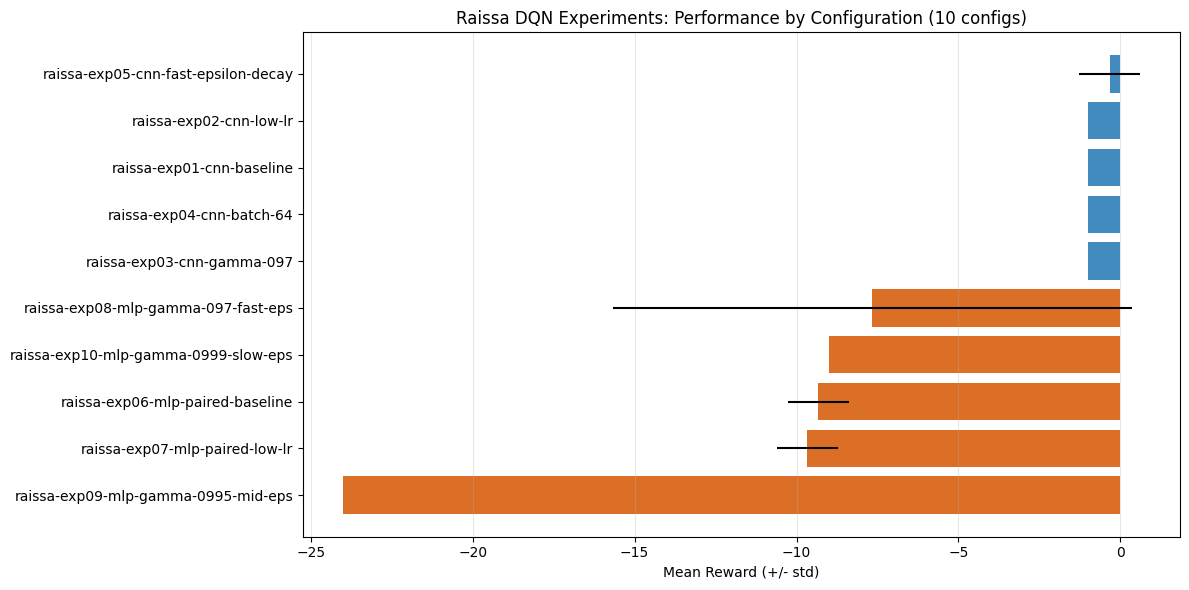

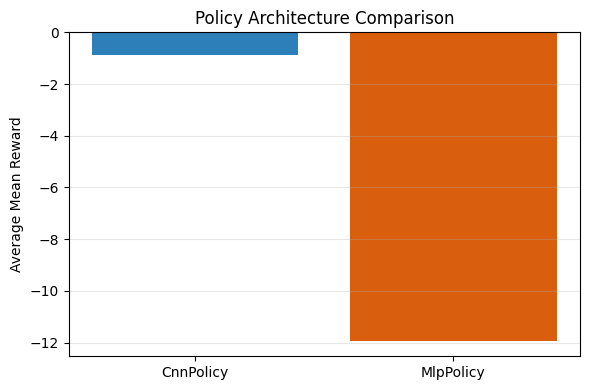

Average reward by policy:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,policy,mean_reward
0,CnnPolicy,-0.866667
1,MlpPolicy,-11.933333


Successful runs: 10 / 10


In [7]:
# Cell 6: Visual summaries (overall ranking + CNN vs MLP comparison)
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"
viz_df = None
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df.to_csv(results_csv_path, index=False)
    print(f"Saved CSV before plotting -> {results_csv_path}")
    viz_df = pd.read_csv(results_csv_path)
else:
    if results_csv_path.exists():
        viz_df = pd.read_csv(results_csv_path)
        print(f"Loaded saved results for plotting: {results_csv_path}")

if viz_df is None or viz_df.empty:
    print("No results available. Run Cell 4 and Cell 5 first.")
else:
    expected_df = pd.DataFrame([
        {"name": e["name"], "policy": e["policy"]}
        for e in experiments
    ])
    plot_df = expected_df.merge(
        viz_df[["name", "policy", "mean_reward", "std_reward"]],
        on=["name", "policy"],
        how="left",
    )
    plot_df["status"] = plot_df["mean_reward"].apply(lambda x: "ok" if pd.notna(x) else "missing")
    plot_df = plot_df.sort_values("mean_reward", ascending=True, na_position="first").copy()
    plot_values = plot_df["mean_reward"].fillna(0.0)
    plot_errors = plot_df["std_reward"].fillna(0.0)

    plt.figure(figsize=(12, 6))
    bar_colors = [
        "#2c7fb8" if (p == "CnnPolicy" and s == "ok") else
        "#d95f0e" if (p == "MlpPolicy" and s == "ok") else
        "#9e9e9e"
        for p, s in zip(plot_df["policy"], plot_df["status"])
    ]
    plt.barh(
        plot_df["name"],
        plot_values,
        xerr=plot_errors,
        color=bar_colors,
        alpha=0.9,
    )
    for y, status in zip(plot_df["name"], plot_df["status"]):
        if status != "ok":
            plt.text(0.2, y, "FAILED/NOT RUN", va="center", fontsize=8, color="#555")
    plt.xlabel("Mean Reward (+/- std)")
    plt.title("Raissa DQN Experiments: Performance by Configuration (10 configs)")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    summary = viz_df.groupby("policy", as_index=False)["mean_reward"].mean()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["policy"], summary["mean_reward"], color=["#2c7fb8", "#d95f0e"])
    plt.ylabel("Average Mean Reward")
    plt.title("Policy Architecture Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Average reward by policy:")
    display(summary)
    print(f"Successful runs: {(plot_df['status'] == 'ok').sum()} / {len(plot_df)}")

    if plot_df["policy"].nunique() < 2:
        print("Note: only one policy appears in successful runs. Check failed_df for errors.")

    if "failed_df" in globals() and isinstance(failed_df, pd.DataFrame) and not failed_df.empty:
        print("\nFailed runs:")
        display(failed_df)

In [8]:
# Cell 7: Export artifacts to Google Drive + optional download links + optional headless gameplay video
if results_df.empty:
    print("results_df is empty. Run Cell 4 first.")
else:
    if BEST_MODEL_PATH.exists():
        print(f"Best model available: {BEST_MODEL_PATH}")
    else:
        print("Best model not found yet. Run Cell 4 first.")

    artifact_paths = [
        ASSIGNMENT_MODEL_PATH,
        BEST_MODEL_PATH,
        RESULTS_CSV,
        RESULTS_MD,
    ]

    print("\nLocal artifacts:")
    for p in artifact_paths:
        print(f" - {p} ({'OK' if p.exists() else 'MISSING'})")

    if DRIVE_MOUNTED and DRIVE_EXPORT_DIR is not None:
        for p in artifact_paths:
            if p.exists():
                dst = DRIVE_EXPORT_DIR / p.name
                shutil.copy(str(p), str(dst))
        print(f"\nCopied artifacts to Google Drive: {DRIVE_EXPORT_DIR}")

    if COLAB_FILES is not None:
        for p in artifact_paths:
            if p.exists():
                COLAB_FILES.download(str(p))
    else:
        print("Download links only work inside Colab.")

    # Optional: record a short headless video using the assignment model (CnnPolicy only).
    RECORD_VIDEO = False
    if RECORD_VIDEO and ASSIGNMENT_MODEL_PATH.exists():
        video_root = VIDEO_DIR / "playback"
        video_root.mkdir(parents=True, exist_ok=True)

        play_env = gym.make(ENV_ID, render_mode="rgb_array")
        play_env = RecordVideo(
            play_env,
            video_folder=str(video_root),
            episode_trigger=lambda episode_id: episode_id % 1 == 0,
            name_prefix="raissa_play",
        )

        model = DQN.load(str(ASSIGNMENT_MODEL_PATH))
        obs, _ = play_env.reset(seed=SEED)
        done = False
        ep_reward = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = play_env.step(int(action))
            ep_reward += float(reward)
            done = terminated or truncated
        play_env.close()

        print(f"Recorded one gameplay episode. Reward: {ep_reward:.2f}")
        print(f"Video folder: {video_root}")

Best model available: /content/results/raissa/models/best_dqn_tennis.zip

Local artifacts:
 - /content/results/raissa/models/dqn_model.zip (OK)
 - /content/results/raissa/models/best_dqn_tennis.zip (OK)
 - /content/results/raissa/tables/raissa_hyperparameter_results.csv (OK)
 - /content/results/raissa/tables/raissa_hyperparameter_results.md (OK)

Copied artifacts to Google Drive: /content/drive/MyDrive/Tenis_dqn_agent/raissa


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 · Load Results
This section rebuilds a clean results table from saved artifacts so you can rerun reporting cells without retraining.

In [9]:
# Rebuild a reporting dataframe from saved CSV (fallback to in-memory results_df).
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"

if results_csv_path.exists():
    report_df = pd.read_csv(results_csv_path)
    print(f"Loaded saved results: {results_csv_path}")
elif "results_df" in globals() and not results_df.empty:
    report_df = results_df.copy()
    print("Using in-memory results_df (not yet saved to CSV).")
else:
    report_df = pd.DataFrame()
    print("No results found. Run Cell 4 and Cell 5 first.")

if not report_df.empty:
    # Standard column names for downstream reporting cells
    df = pd.DataFrame({
        "Exp": report_df["name"],
        "Policy": report_df["policy"],
        "lr": report_df["learning_rate"],
        "gamma": report_df["gamma"],
        "batch": report_df["batch_size"],
        "eps_start": report_df["exploration_initial_eps"],
        "eps_end": report_df["exploration_final_eps"],
        "eps_frac": report_df["exploration_fraction"],
        "mean_reward": report_df["mean_reward"],
        "std_reward": report_df["std_reward"],
        "train_min": report_df["train_minutes"],
    })
    df = df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
    display(df)

Loaded saved results: /content/results/raissa/tables/raissa_hyperparameter_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Exp,Policy,lr,gamma,batch,eps_start,eps_end,eps_frac,mean_reward,std_reward,train_min
0,raissa-exp05-cnn-fast-epsilon-decay,CnnPolicy,0.00010,0.990,64,1.0,0.01,0.05,-0.333333,0.942809,32.541673
1,raissa-exp01-cnn-baseline,CnnPolicy,0.00010,0.990,32,1.0,0.01,0.10,-1.000000,0.000000,22.952055
2,raissa-exp02-cnn-low-lr,CnnPolicy,0.00005,0.990,32,1.0,0.01,0.10,-1.000000,0.000000,23.748941
3,raissa-exp03-cnn-gamma-097,CnnPolicy,0.00010,0.970,32,1.0,0.01,0.10,-1.000000,0.000000,21.256691
4,raissa-exp04-cnn-batch-64,CnnPolicy,0.00010,0.990,64,1.0,0.01,0.10,-1.000000,0.000000,32.527165
5,raissa-exp08-mlp-gamma-097-fast-eps,MlpPolicy,0.00010,0.970,64,1.0,0.01,0.05,-7.666667,8.013877,2.998289
6,raissa-exp10-mlp-gamma-0999-slow-eps,MlpPolicy,0.00010,0.999,64,1.0,0.05,0.30,-9.000000,0.000000,3.320446
7,raissa-exp06-mlp-paired-baseline,MlpPolicy,0.00010,0.990,32,1.0,0.01,0.10,-9.333333,0.942809,4.368831
8,raissa-exp07-mlp-paired-low-lr,MlpPolicy,0.00005,0.990,32,1.0,0.01,0.10,-9.666667,0.942809,4.833291
9,raissa-exp09-mlp-gamma-0995-mid-eps,MlpPolicy,0.00010,0.995,64,1.0,0.02,0.15,-24.000000,0.000000,2.958738


## 9 · Hyperparameter Table Exact Assignment Format


In [10]:
# Build assignment-format table from your experiment definitions and merge real rewards when available.
def _default_behavior(name: str, policy: str) -> str:
    if policy == "MlpPolicy":
        return f"[{name}] MLP ablation run. Usually weaker than CNN on pixel-based Atari due to reduced visual feature extraction."
    return f"[{name}] CNN run. Evaluate reward trend and stability against baseline to determine if this config helps or hurts."

assignment_rows = []
for exp_cfg in experiments:
    hp = exp_cfg["hp"]
    hset = (
        f"lr={hp['learning_rate']}, gamma={hp['gamma']}, batch={hp['batch_size']}, "
        f"epsilon_start={hp['exploration_initial_eps']}, epsilon_end={hp['exploration_final_eps']}, "
        f"epsilon_decay={hp['exploration_fraction']}"
    )
    assignment_rows.append({
        "Member Name": "Raissa",
        "Hyperparameter Set": hset,
        "Noted Behavior": _default_behavior(exp_cfg["name"], exp_cfg["policy"]),
        "Exp": exp_cfg["name"],
    })

assignment_df = pd.DataFrame(assignment_rows)

if "df" in globals() and not df.empty:
    reward_map = dict(zip(df["Exp"], zip(df["mean_reward"], df["std_reward"])))
    merged_behavior = []
    for _, row in assignment_df.iterrows():
        mr, sr = reward_map.get(row["Exp"], (None, None))
        if mr is None:
            merged_behavior.append(row["Noted Behavior"] + " | Mean Reward: not run")
        else:
            merged_behavior.append(row["Noted Behavior"] + f" | Mean Reward: {mr:.2f} +/- {sr:.2f}")
    assignment_df["Noted Behavior"] = merged_behavior

display(assignment_df[["Member Name", "Hyperparameter Set", "Noted Behavior"]])

assignment_table_path = TABLE_DIR / "raissa_assignment_table.csv"
assignment_df[["Member Name", "Hyperparameter Set", "Noted Behavior"]].to_csv(assignment_table_path, index=False)
print(f"Saved assignment-format table -> {assignment_table_path}")

,Member Name,Hyperparameter Set,Noted Behavior
0,Raissa,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",[raissa-exp01-cnn-baseline] CNN run. Evaluate ...
1,Raissa,"lr=5e-05, gamma=0.99, batch=32, epsilon_start=...",[raissa-exp02-cnn-low-lr] CNN run. Evaluate re...
2,Raissa,"lr=0.0001, gamma=0.97, batch=32, epsilon_start...",[raissa-exp03-cnn-gamma-097] CNN run. Evaluate...
3,Raissa,"lr=0.0001, gamma=0.99, batch=64, epsilon_start...",[raissa-exp04-cnn-batch-64] CNN run. Evaluate ...
4,Raissa,"lr=0.0001, gamma=0.99, batch=64, epsilon_start...",[raissa-exp05-cnn-fast-epsilon-decay] CNN run....
5,Raissa,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",[raissa-exp06-mlp-paired-baseline] MLP ablatio...
6,Raissa,"lr=5e-05, gamma=0.99, batch=32, epsilon_start=...",[raissa-exp07-mlp-paired-low-lr] MLP ablation ...
7,Raissa,"lr=0.0001, gamma=0.97, batch=64, epsilon_start...",[raissa-exp08-mlp-gamma-097-fast-eps] MLP abla...
8,Raissa,"lr=0.0001, gamma=0.995, batch=64, epsilon_star...",[raissa-exp09-mlp-gamma-0995-mid-eps] MLP abla...
9,Raissa,"lr=0.0001, gamma=0.999, batch=64, epsilon_star...",[raissa-exp10-mlp-gamma-0999-slow-eps] MLP abl...


Saved assignment-format table -> /content/results/raissa/tables/raissa_assignment_table.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 10 · Reward Comparison Chart

Saved CSV before plotting -> /content/results/raissa/tables/raissa_hyperparameter_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


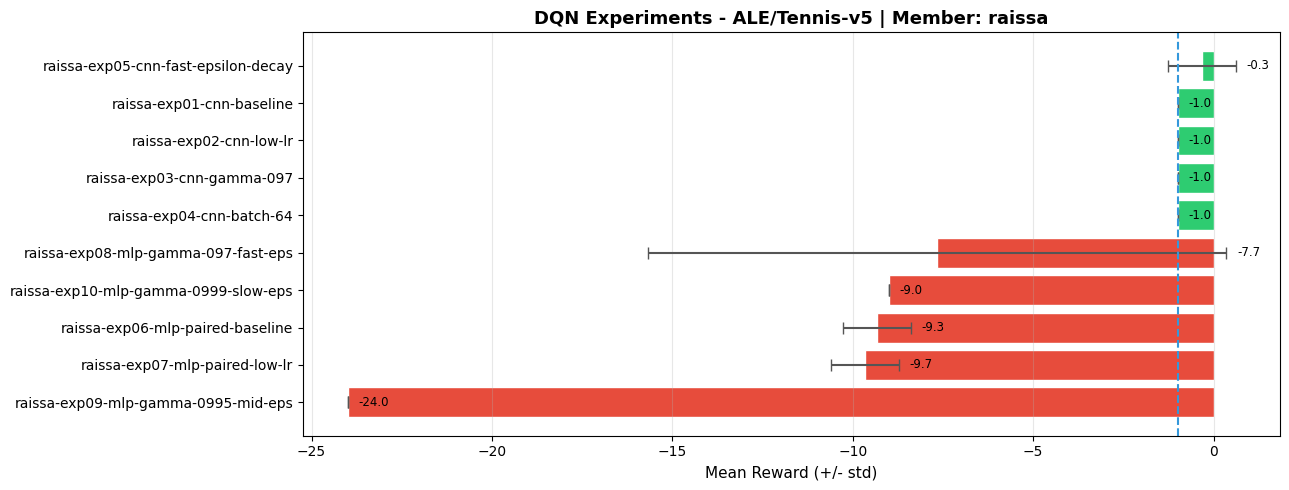

Saved -> /content/results/raissa/tables/raissa_reward_comparison.png
Successful runs in chart: 10 / 10


In [11]:
# Cell 10: Reward Comparison Chart
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df.to_csv(results_csv_path, index=False)
    print(f"Saved CSV before plotting -> {results_csv_path}")

plot_df = None
if "df" in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:
    plot_df = df.copy()
else:
    if results_csv_path.exists():
        report_df = pd.read_csv(results_csv_path)
        plot_df = pd.DataFrame({
            "Exp": report_df["name"],
            "Policy": report_df["policy"],
            "mean_reward": report_df["mean_reward"],
            "std_reward": report_df["std_reward"],
        }).sort_values("mean_reward", ascending=False).reset_index(drop=True)
        print(f"Loaded saved results for reward chart: {results_csv_path}")

if plot_df is not None and len(plot_df) > 0:
    expected_df = pd.DataFrame([
        {"Exp": e["name"], "Policy": e["policy"]}
        for e in experiments
    ])
    plot_df = expected_df.merge(
        plot_df[["Exp", "Policy", "mean_reward", "std_reward"]],
        on=["Exp", "Policy"],
        how="left",
    )
    plot_df["status"] = plot_df["mean_reward"].apply(lambda x: "ok" if pd.notna(x) else "missing")
    plot_df = plot_df.sort_values("mean_reward", ascending=False, na_position="last").reset_index(drop=True)
    y_values = plot_df["mean_reward"].fillna(0.0)
    y_errors = plot_df["std_reward"].fillna(0.0)
    fig, ax = plt.subplots(figsize=(13, 5))
    colors = [
        "#2ecc71" if ("Cnn" in p and s == "ok") else
        "#e74c3c" if ("Mlp" in p and s == "ok") else
        "#9e9e9e"
        for p, s in zip(plot_df["Policy"], plot_df["status"])
    ]
    bars = ax.barh(
        plot_df["Exp"],
        y_values,
        xerr=y_errors,
        color=colors,
        edgecolor="white",
        error_kw=dict(ecolor="#555", capsize=4, lw=1.5),
    )

    for bar, val, std, status in zip(bars, y_values, y_errors, plot_df["status"]):
        if status == "ok":
            ax.text(
                bar.get_width() + abs(std) + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}",
                va="center",
                fontsize=8.5,
            )
        else:
            ax.text(0.2, bar.get_y() + bar.get_height() / 2, "FAILED/NOT RUN", va="center", fontsize=8, color="#555")

    baseline_val = plot_df[plot_df["Exp"] == "raissa-exp01-cnn-baseline"]["mean_reward"].values
    if len(baseline_val):
        ax.axvline(baseline_val[0], color="#3498db", ls="--", lw=1.5, label="Baseline")

    ax.set_xlabel("Mean Reward (+/- std)", fontsize=11)
    ax.set_title(f"DQN Experiments - ALE/Tennis-v5 | Member: {MEMBER}", fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    reward_plot_path = TABLE_DIR / "raissa_reward_comparison.png"
    plt.savefig(reward_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {reward_plot_path}")
    print(f"Successful runs in chart: {(plot_df['status'] == 'ok').sum()} / {len(plot_df)}")
else:
    print("No results yet - run Cell 4 and Cell 5 first.")

## 11 · Training Curves (Reward over Time)

Saved CSV before plotting curves -> /content/results/raissa/tables/raissa_hyperparameter_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


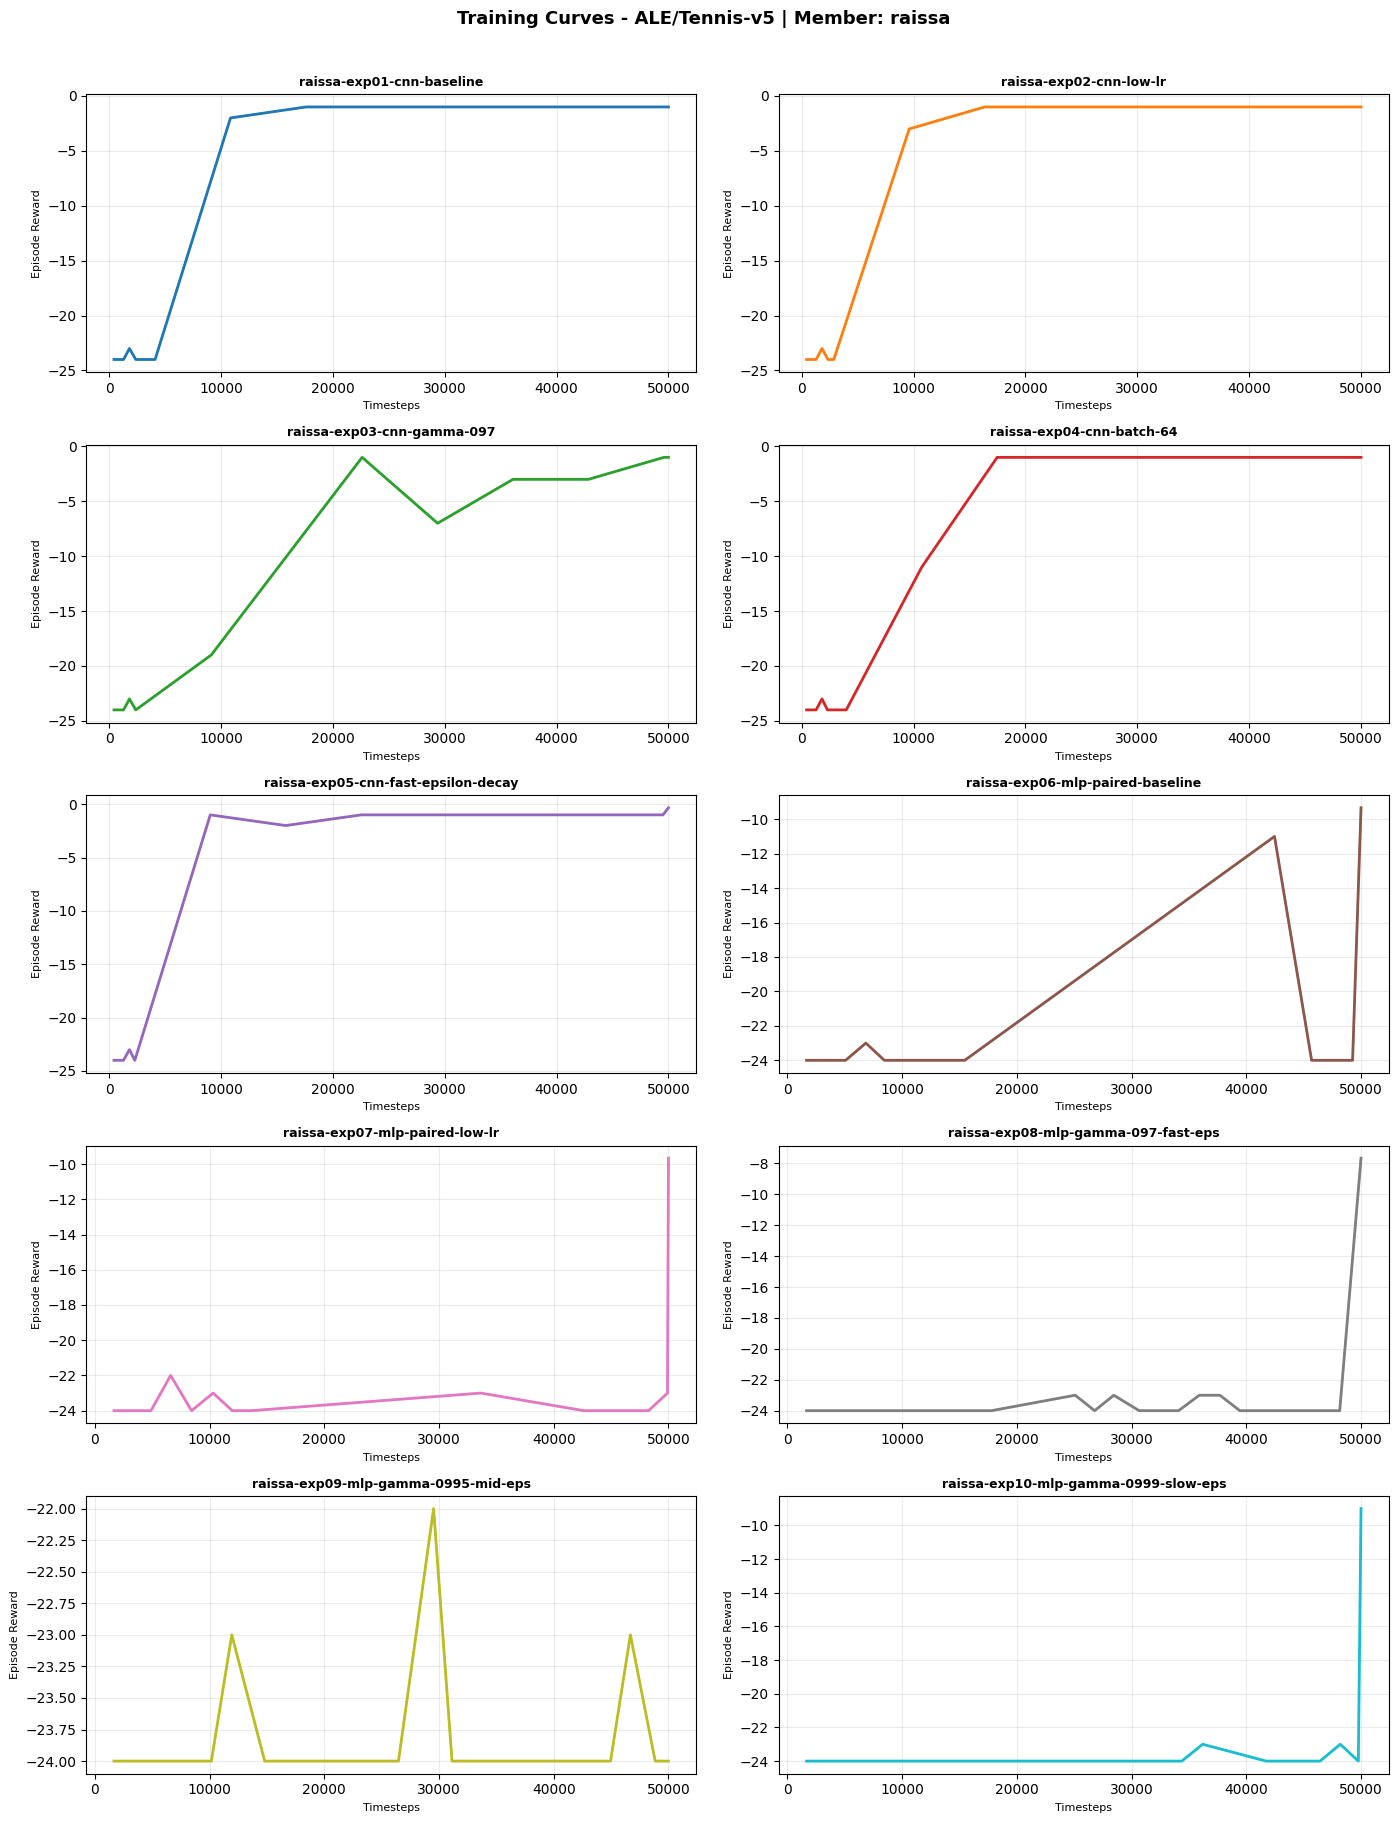

Saved -> /content/results/raissa/tables/raissa_training_curves.png


In [12]:
# Cell 11: Training curves with robust handling for sparse/no-episode logs.
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df.to_csv(results_csv_path, index=False)
    print(f"Saved CSV before plotting curves -> {results_csv_path}")

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
palette = plt.cm.tab10.colors

for i, cfg in enumerate(experiments):
    exp_name = cfg["name"]
    csv_path = LOG_DIR / f"{exp_name}_training_metrics.csv"
    eval_json_path = BASE_DIR / exp_name / f"{exp_name}_eval.json"
    ax = axes[i]

    plotted = False
    if csv_path.exists():
        try:
            log_df = pd.read_csv(csv_path)
            if {"timestep", "ep_reward"}.issubset(log_df.columns) and not log_df.empty:
                log_df = log_df.sort_values("timestep").drop_duplicates(subset=["timestep"], keep="last")
                log_df["ep_reward"] = pd.to_numeric(log_df["ep_reward"], errors="coerce")
                valid = log_df.dropna(subset=["ep_reward"]).copy()

                if not valid.empty:
                    w = max(1, len(valid) // 20)
                    smooth = valid["ep_reward"].rolling(w, min_periods=1).mean()
                    ax.plot(valid["timestep"], valid["ep_reward"], alpha=0.25, color=palette[i % 10], label="raw")
                    ax.plot(valid["timestep"], smooth, color=palette[i % 10], lw=2, label="smoothed")
                    if "row_type" in valid.columns and (valid["row_type"] == "progress").any():
                        progress_df = valid[valid["row_type"] == "progress"]
                        ax.scatter(progress_df["timestep"], progress_df["ep_reward"], s=8, alpha=0.5, color=palette[i % 10])
                    plotted = True
        except Exception as e:
            ax.text(0.5, 0.5, f"CSV read error: {type(e).__name__}", ha="center", va="center", transform=ax.transAxes, color="gray")

    # Fallback: plot final evaluation reward from eval JSON when episode curves are unavailable.
    if not plotted and eval_json_path.exists():
        try:
            with open(eval_json_path, "r", encoding="utf-8") as f:
                ev = json.load(f)
            eval_mean = float(ev.get("mean_reward", 0.0))
            eval_std = float(ev.get("std_reward", 0.0))
            total_ts = int(ev.get("total_timesteps", 50_000))
            ax.plot([0, total_ts], [eval_mean, eval_mean], color=palette[i % 10], lw=2)
            ax.fill_between([0, total_ts], [eval_mean - eval_std, eval_mean - eval_std], [eval_mean + eval_std, eval_mean + eval_std], color=palette[i % 10], alpha=0.15)
            ax.text(0.02, 0.92, "eval fallback", transform=ax.transAxes, fontsize=8, color="#555")
            plotted = True
        except Exception as e:
            ax.text(0.5, 0.5, f"Eval JSON error: {type(e).__name__}", ha="center", va="center", transform=ax.transAxes, color="gray")

    if not plotted:
        ax.text(0.5, 0.5, "No usable log data", ha="center", va="center", transform=ax.transAxes, color="gray")

    ax.set_title(exp_name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Timesteps", fontsize=8)
    ax.set_ylabel("Episode Reward", fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle(f"Training Curves - ALE/Tennis-v5 | Member: {MEMBER}", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
curves_path = TABLE_DIR / "raissa_training_curves.png"
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {curves_path}")

## 12 · Save Best Model as dqn_model.zip

In [13]:
if "df" in globals() and len(df) > 0:
    best_row = df.loc[df["mean_reward"].idxmax()]
    best_exp = best_row["Exp"]
    print(f"Best experiment: {best_exp}")
    print(f"Mean reward: {best_row['mean_reward']:.2f}")

    src = MODEL_DIR / f"{best_exp}.zip"
    alt = MODEL_DIR / "best_dqn_tennis.zip"
    target = MODEL_DIR / "dqn_model.zip"

    if src.exists():
        shutil.copy(str(src), str(target))
        print(f"Saved -> {target}")
    elif alt.exists():
        shutil.copy(str(alt), str(target))
        print(f"Saved fallback best -> {target}")
    else:
        print("[WARNING] Model zip not found. Run Cell 4 first.")
else:
    print("No results. Run Cell 4 and Cell 8 first.")

Best experiment: raissa-exp05-cnn-fast-epsilon-decay
Mean reward: -0.33
Saved -> /content/results/raissa/models/dqn_model.zip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13 · Key Insights Summary

In [14]:
if "df" in globals() and len(df) > 0:
    best = df.loc[df["mean_reward"].idxmax()]
    worst = df.loc[df["mean_reward"].idxmin()]
    cnn_mean = df[df["Policy"] == "CnnPolicy"]["mean_reward"].mean()
    mlp_mean = df[df["Policy"] == "MlpPolicy"]["mean_reward"].mean()

    best_exp = best["Exp"]
    best_mean = float(best["mean_reward"])
    best_std = float(best["std_reward"])
    best_lr = best["lr"]
    best_gamma = best["gamma"]
    best_batch = int(best["batch"])
    best_eps_start = best["eps_start"]
    best_eps_end = best["eps_end"]
    best_eps_frac = best["eps_frac"]

    worst_exp = worst["Exp"]
    worst_mean = float(worst["mean_reward"] )
    worst_std = float(worst["std_reward"])

    print("=" * 65)
    print(f"  KEY INSIGHTS - Member: {MEMBER}")
    print("=" * 65)
    print(f"\n1. BEST CONFIG: {best_exp}")
    print(f"   Mean reward : {best_mean:.2f} +/- {best_std:.2f}")
    print(f"   lr={best_lr}, gamma={best_gamma}, batch={best_batch}")
    print(f"   eps_start={best_eps_start}, eps_end={best_eps_end}, eps_frac={best_eps_frac}")

    print(f"\n2. WORST CONFIG: {worst_exp}")
    print(f"   Mean reward : {worst_mean:.2f} +/- {worst_std:.2f}")

    print("\n3. CNN vs MLP")
    print(f"   CNN mean reward : {cnn_mean:.2f}")
    print(f"   MLP mean reward : {mlp_mean:.2f}")
    winner = "CNN" if cnn_mean > mlp_mean else "MLP"
    print(f"   {winner} is better by {abs(cnn_mean - mlp_mean):.2f} points")

    print("\n4. Hyperparameter Sensitivity")
    print("   Compare runs by LR, gamma, batch size, and epsilon decay to explain performance trade-offs.")
    print("=" * 65)
else:
    print("No results. Run Cell 4 and Cell 8 first.")

  KEY INSIGHTS - Member: raissa

1. BEST CONFIG: raissa-exp05-cnn-fast-epsilon-decay
   Mean reward : -0.33 +/- 0.94
   lr=0.0001, gamma=0.99, batch=64
   eps_start=1.0, eps_end=0.01, eps_frac=0.05

2. WORST CONFIG: raissa-exp09-mlp-gamma-0995-mid-eps
   Mean reward : -24.00 +/- 0.00

3. CNN vs MLP
   CNN mean reward : -0.87
   MLP mean reward : -11.93
   CNN is better by 11.07 points

4. Hyperparameter Sensitivity
   Compare runs by LR, gamma, batch size, and epsilon decay to explain performance trade-offs.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 14 · Environment Demo Video (via play.py)
This section runs scripts/play.py with the best saved model and embeds the generated gameplay clip.

In [15]:
# Cell 14: Run scripts/play.py to generate and preview gameplay video.
from IPython.display import Video, display

DEMO_EPISODES = 1
DEMO_MAX_STEPS = 2_000
DEMO_SEED = 42
DEMO_VIDEO_DIR = VIDEO_DIR / "play_script_demo"
DEMO_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

candidate_models = [
    ASSIGNMENT_MODEL_PATH,
    BEST_MODEL_PATH,
    MODEL_DIR / "dqn_model.zip",
]
model_path = next((p for p in candidate_models if p.exists()), None)

if model_path is None:
    raise FileNotFoundError(
        "No trained model found. Run Cell 4 first so dqn_model.zip or best_dqn_tennis.zip is created."
    )
if not PLAY_SCRIPT.exists():
    raise FileNotFoundError(f"play.py not found at: {PLAY_SCRIPT}")

policy_guess = "CnnPolicy"
if "df" in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:
    best_row = df.loc[df["mean_reward"].idxmax()]
    policy_guess = str(best_row["Policy"])
elif "results_df" in globals() and isinstance(results_df, pd.DataFrame) and len(results_df) > 0:
    best_row = results_df.loc[results_df["mean_reward"].idxmax()]
    policy_guess = str(best_row["policy"])

cmd = [
    sys.executable,
    str(PLAY_SCRIPT),
    "--model-path", str(model_path),
    "--env-id", ENV_ID,
    "--policy", policy_guess,
    "--episodes", str(DEMO_EPISODES),
    "--seed", str(DEMO_SEED),
    "--max-steps", str(DEMO_MAX_STEPS),
    "--record-video",
    "--video-dir", str(DEMO_VIDEO_DIR),
    "--video-prefix", f"{MEMBER}_play",
]

print("Running play.py...")
run = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)
if run.stdout:
    print(run.stdout[-2000:])
if run.returncode != 0:
    print(run.stderr[-2000:] if run.stderr else "play.py failed.")
    raise RuntimeError("play.py execution failed")

mp4_files = sorted(DEMO_VIDEO_DIR.glob("*.mp4"), key=lambda p: p.stat().st_mtime)
if mp4_files:
    latest_video = mp4_files[-1]
    print(f"Video saved: {latest_video}")
    display(Video(str(latest_video), embed=True, html_attributes="controls loop"))
else:
    raise RuntimeError("No video generated. Check play.py output above.")

Running play.py...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saving video to /content/results/raissa/videos/play_script_demo/raissa_play-step-0-to-step-2000.mp4
Moviepy - Building video /content/results/raissa/videos/play_script_demo/raissa_play-step-0-to-step-2000.mp4.
Moviepy - Writing video /content/results/raissa/videos/play_script_demo/raissa_play-step-0-to-step-2000.mp4

Moviepy - Done !
Moviepy - video ready /content/results/raissa/videos/play_script_demo/raissa_play-step-0-to-step-2000.mp4
Episode 1/1 | steps=2000 | reward=-1.00
Average reward over 1 episodes: -1.00
Video saved: /content/results/raissa/videos/play_script_demo/raissa_play-step-0-to-step-2000.mp4

Video saved: /content/results/raissa/videos/play_script_demo/raissa_play-step-0-to-step-2000.mp4
